# SERGIO GRN QC

**Instructions**
- Set `INPUT_DIR` to the folder produced by `batch_runner.ipynb` that contains `nodes.csv`, `edges_tf_tf.csv`, `edges_tf_target.csv`, `README.csv`, `input_targets.txt`, `input_regs.txt`.
- Optionally change `OUT_DIR` (defaults to `<INPUT_DIR>/qc`).
- Run all cells.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from math import cos, sin, pi

# --- User parameters ---
INPUT_DIR = Path('../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn')  # <-- change to your folder
OUT_DIR = INPUT_DIR / 'qc'
OUT_DIR.mkdir(exist_ok=True, parents=True)

print('Input:', INPUT_DIR)
print('Output:', OUT_DIR)


Input: ../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn
Output: ../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn/qc


In [2]:
# Load mandatory CSVs
nodes = pd.read_csv(INPUT_DIR / 'nodes.csv')
edges_tf_tf = pd.read_csv(INPUT_DIR / 'edges_tf_tf.csv')
edges_tf_tg = pd.read_csv(INPUT_DIR / 'edges_tf_target.csv')
readme_path = INPUT_DIR / 'README.csv'
settings = pd.read_csv(readme_path) if readme_path.exists() else None
display(settings.head(20) if settings is not None else 'No README.csv found')

# Optional SERGIO inputs (.txt, variable-length)
targets_txt = INPUT_DIR / 'input_targets.txt'
regs_txt = INPUT_DIR / 'input_regs.txt'
print('Found input_targets.txt:', targets_txt.exists())
print('Found input_regs.txt:', regs_txt.exists())

tf_nodes = nodes[nodes['kind']=='TF'].copy()
tg_nodes = nodes[nodes['kind']=='TG'].copy()
print(f"TFs: {len(tf_nodes)} | Targets: {len(tg_nodes)} | TF->TF edges: {len(edges_tf_tf)} | TF->TG edges: {len(edges_tf_tg)}")


,key,value
0,seed,12345
1,n_communities,5
2,tf_per_comm_low,15
3,tf_per_comm_high,20
4,layer_props,"[0.2, 0.5, 0.3]"
5,within_mu_level,mid
6,in_degree_cap,4
7,motif_fraction,0.15
8,inter_density,five_per_pair
9,inter_topdown_bias,0.8


Found input_targets.txt: True
Found input_regs.txt: True
TFs: 87 | Targets: 800 | TF->TF edges: 266 | TF->TG edges: 2825


## Parse SERGIO inputs (.txt) and validate (optional but recommended)

In [3]:
def parse_input_targets_txt(path: Path):
    rows = []
    if not path.exists():
        return pd.DataFrame(columns=['target_id','n_reg','reg_list','K_list','hill_list'])
    with open(path) as f:
        for ln, line in enumerate(f, 1):
            parts = [p.strip() for p in line.strip().split(',')]
            if len(parts) < 2:
                print(f'[WARN] line {ln} too short, skipping');
                continue
            tgt = int(float(parts[0]))
            nreg = int(float(parts[1]))
            rest = parts[2:]
            if len(rest) != 3*nreg:
                # tolerate extra whitespace or accidental trailing comma issues
                if len(rest) < 3*nreg:
                    print(f'[WARN] line {ln}: expected {3*nreg} trailing fields, got {len(rest)}')
                # attempt best-effort pad with empty, though generator should be correct
                rest = rest + ['']*(3*nreg - len(rest))
            regs = [int(float(x)) for x in rest[:nreg]]
            Ks = [float(x) for x in rest[nreg:2*nreg]]
            hills = [float(x) for x in rest[2*nreg:3*nreg]]
            rows.append({'target_id': tgt, 'n_reg': nreg, 'reg_list': regs, 'K_list': Ks, 'hill_list': hills})
    return pd.DataFrame(rows)

def parse_input_regs_txt(path: Path):
    rows = []
    if not path.exists():
        return pd.DataFrame(columns=['mr_id'])
    with open(path) as f:
        for ln, line in enumerate(f, 1):
            parts = [p.strip() for p in line.strip().split(',')]
            if len(parts) < 2:
                print(f'[WARN] line {ln} too short, skipping');
                continue
            mr = int(float(parts[0]))
            prods = [float(x) for x in parts[1:]]
            rows.append({'mr_id': mr, 'prods': prods})
    # normalize to a wide df for convenience
    max_bins = max((len(r['prods']) for r in rows), default=0)
    out_rows = []
    for r in rows:
        d = {'mr_id': r['mr_id']}
        for i, val in enumerate(r['prods'], 1):
            d[f'prod_bin{i}'] = val
        out_rows.append(d)
    return pd.DataFrame(out_rows)

df_targets_txt = parse_input_targets_txt(targets_txt)
df_regs_txt = parse_input_regs_txt(regs_txt)

display(df_targets_txt.head())
display(df_regs_txt.head())

# Validate K and hills if files are present
checks = {}
if not df_targets_txt.empty:
    all_K = np.concatenate(df_targets_txt['K_list'].to_numpy(), axis=None)
    all_H = np.concatenate(df_targets_txt['hill_list'].to_numpy(), axis=None)
    checks['K_min'] = float(np.min(all_K)) if all_K.size else None
    checks['K_max'] = float(np.max(all_K)) if all_K.size else None
    checks['K_frac_negative'] = float(np.mean(all_K < 0)) if all_K.size else None
    checks['H_unique_values'] = sorted(list(np.unique(np.round(all_H, 6)))) if all_H.size else []
    print('SERGIO input checks:', checks)
    pd.Series(checks).to_csv(OUT_DIR / 'sergio_inputs_checks.csv')

checks

,target_id,n_reg,reg_list,K_list,hill_list
0,4,4,"[0, 3, 2, 1]","[-3.4723098598765167, 4.7370844775390175, -2.5...","[2.0, 2.0, 2.0, 2.0]"
1,5,3,"[0, 2, 1]","[-3.494502719251784, 3.9440663555368727, 3.620...","[2.0, 2.0, 2.0]"
2,6,4,"[1, 2, 0, 3]","[3.5973477155935205, 2.015928676366137, 4.0629...","[2.0, 2.0, 2.0, 2.0]"
3,7,3,"[1, 0, 2]","[4.831122529771069, 3.4604802411364175, -2.389...","[2.0, 2.0, 2.0]"
4,8,1,[0],[4.533846820375162],[2.0]


,mr_id,prod_bin1
0,0,3.395956
1,1,3.934677
2,2,3.017054
3,3,2.130040
4,18,2.764756


SERGIO input checks: {'K_min': -4.996044982899977, 'K_max': 4.999263047091665, 'K_frac_negative': 0.29472662568747976, 'H_unique_values': [np.float64(2.0)]}


{'K_min': -4.996044982899977,
 'K_max': 4.999263047091665,
 'K_frac_negative': 0.29472662568747976,
 'H_unique_values': [np.float64(2.0)]}

## 1) TF→TF Graph Visualization (colored by community)

/tmp/ipykernel_2613880/3579514923.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', nC)


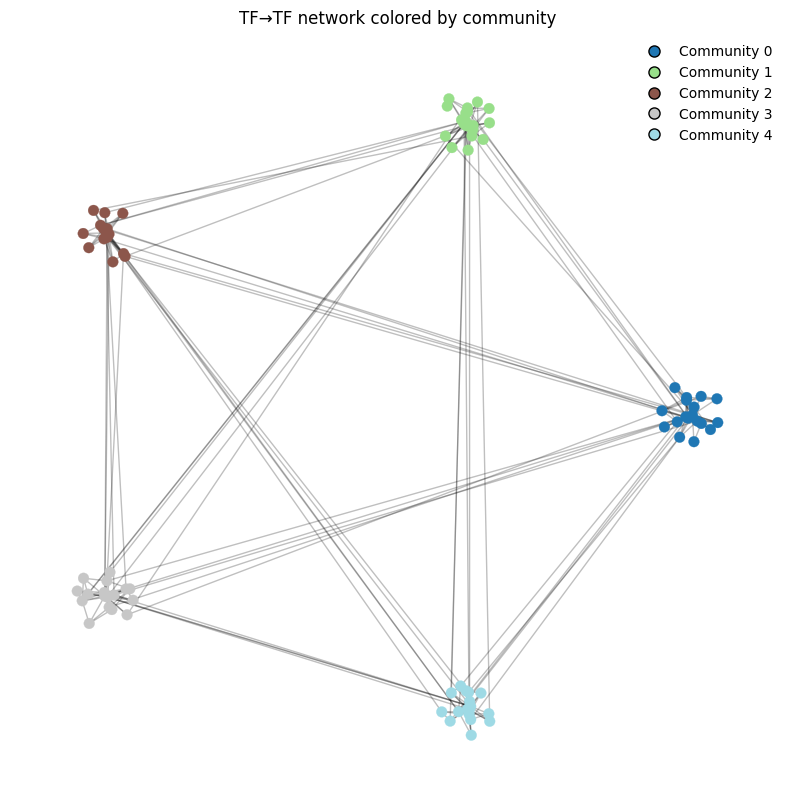

In [4]:
G = nx.DiGraph()
for _, r in nodes[nodes['kind']=='TF'].iterrows():
    G.add_node(int(r['gene_id']), community=int(r['community']), layer=str(r['layer']), name=str(r['gene_name']))
for _, r in edges_tf_tf.iterrows():
    G.add_edge(int(r['src']), int(r['dst']))

communities = sorted(nodes[nodes['kind']=='TF']['community'].unique())
nC = len(communities)
R = 5.0 * np.sqrt(max(1, nC))
centers = {c: (R*cos(2*pi*i/nC), R*sin(2*pi*i/nC)) for i,c in enumerate(communities)}

pos = {}
for c in communities:
    nodes_c = [n for n,data in G.nodes(data=True) if data['community']==c]
    if len(nodes_c) == 1:
        local = {nodes_c[0]: (0.0, 0.0)}
    else:
        local = nx.spring_layout(G.subgraph(nodes_c), seed=42, k=0.7)
    cx, cy = centers[c]
    for n, (x,y) in local.items():
        pos[n] = (x + cx, y + cy)

import matplotlib as mpl
cmap = plt.cm.get_cmap('tab20', nC)
node_colors = [cmap(G.nodes[n]['community'] % nC) for n in G.nodes()]

plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=60, linewidths=0.2)
nx.draw_networkx_edges(G, pos, alpha=0.25, arrows=False)
plt.axis('off')
handles = [mpl.lines.Line2D([0],[0], marker='o', linestyle='', markersize=8, 
                            markerfacecolor=cmap(ci), markeredgecolor='k', label=f'Community {c}') 
           for ci,c in enumerate(communities)]
plt.legend(handles=handles, loc='upper right', frameon=False)
plt.title('TF→TF network colored by community')
plt.show()


## 2) Average in-degree and out-degree per community (TF→TF only)

In [5]:
deg_in = dict(G.in_degree())
deg_out = dict(G.out_degree())
tf_nodes2 = nodes[nodes['kind']=='TF'].copy()
tf_nodes2['in_degree'] = tf_nodes2['gene_id'].map(deg_in)
tf_nodes2['out_degree'] = tf_nodes2['gene_id'].map(deg_out)
deg_by_comm = tf_nodes2.groupby('community').agg(
    avg_in_degree=('in_degree','mean'),
    avg_out_degree=('out_degree','mean'),
    n_tfs=('gene_id','count')
).reset_index()
display(deg_by_comm)
deg_by_comm.to_csv(OUT_DIR / 'avg_degrees_by_community.csv', index=False)
print('Saved:', OUT_DIR / 'avg_degrees_by_community.csv')


,community,avg_in_degree,avg_out_degree,n_tfs
0,0,2.500000,3.611111,18
1,1,2.750000,3.250000,20
2,2,3.200000,3.200000,15
3,3,3.352941,2.705882,17
4,4,3.588235,2.470588,17


Saved: ../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn/qc/avg_degrees_by_community.csv


## 3) TF→TF edges between communities (counts and matrix)

In [6]:
e = edges_tf_tf.merge(nodes[['gene_id','community']].rename(columns={'gene_id':'src','community':'src_comm'}), on='src')\
                 .merge(nodes[['gene_id','community']].rename(columns={'gene_id':'dst','community':'dst_comm'}), on='dst')
pair_counts = e.groupby(['src_comm','dst_comm']).size().reset_index(name='n_edges')
matrix = pair_counts.pivot(index='src_comm', columns='dst_comm', values='n_edges').fillna(0).astype(int)
display(pair_counts)
display(matrix)
pair_counts.to_csv(OUT_DIR / 'edges_between_communities_long.csv', index=False)
matrix.to_csv(OUT_DIR / 'edges_between_communities_matrix.csv')
print('Saved:', OUT_DIR / 'edges_between_communities_long.csv')
print('Saved:', OUT_DIR / 'edges_between_communities_matrix.csv')


,src_comm,dst_comm,n_edges
0,0,0,45
1,0,1,5
2,0,2,5
3,0,3,5
4,0,4,5
5,1,1,50
6,1,2,5
7,1,3,5
8,1,4,5
9,2,2,38


dst_comm,0,1,2,3,4
src_comm,,,,,
0,45,5,5,5,5
1,0,50,5,5,5
2,0,0,38,5,5
3,0,0,0,42,4
4,0,0,0,0,42


Saved: ../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn/qc/edges_between_communities_long.csv
Saved: ../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn/qc/edges_between_communities_matrix.csv


## 4) Target in-degree and dominant-community proportion

In [7]:
tf_comm = nodes.set_index('gene_id')['community'].to_dict()
tg_names = nodes[nodes['kind']=='TG'][['gene_id','gene_name']].rename(columns={'gene_id':'target_id'})
edges_tg_ext = edges_tf_tg.copy()
edges_tg_ext['src_comm'] = edges_tg_ext['src'].map(tf_comm)
grp = edges_tg_ext.groupby(['dst','src_comm']).size().reset_index(name='count')
total_in = grp.groupby('dst')['count'].sum().rename('in_degree').reset_index()
dom = grp.sort_values(['dst','count'], ascending=[True,False]).drop_duplicates('dst')
dom = dom.rename(columns={'src_comm':'dominant_comm','count':'dominant_count'})
summary_tg = total_in.merge(dom, on='dst').merge(tg_names, left_on='dst', right_on='target_id', how='left')
summary_tg['dominant_prop'] = summary_tg['dominant_count'] / summary_tg['in_degree']
summary_tg = summary_tg[['target_id','gene_name','in_degree','dominant_comm','dominant_count','dominant_prop']]
display(summary_tg.head(20))
summary_tg.to_csv(OUT_DIR / 'targets_in_degree_and_dominant_comm.csv', index=False)
print('Saved:', OUT_DIR / 'targets_in_degree_and_dominant_comm.csv')


,target_id,gene_name,in_degree,dominant_comm,dominant_count,dominant_prop
0,87,TG_0,4,1,2,0.500000
1,88,TG_1,4,3,3,0.750000
2,89,TG_2,2,1,1,0.500000
3,90,TG_3,6,4,3,0.500000
4,91,TG_4,4,3,2,0.500000
5,92,TG_5,5,2,3,0.600000
6,93,TG_6,4,3,3,0.750000
7,94,TG_7,3,4,2,0.666667
8,95,TG_8,2,3,1,0.500000
9,96,TG_9,5,1,2,0.400000


Saved: ../../data/simulated/C5_TG800_B[1]_U1000_P400_S12345/grn/qc/targets_in_degree_and_dominant_comm.csv


## (Optional) Compare repression rate to requested `p_repression`

In [8]:
req_p = None
if settings is not None:
    try:
        req_p = float(settings.loc[settings['key']=='p_repression','value'].values[0])
    except Exception as e:
        req_p = None

# derive actual fraction from edges CSV (sign of K)
if 'K' in edges_tf_tf.columns and 'K' in edges_tf_tg.columns:
    allK = pd.concat([edges_tf_tf['K'], edges_tf_tg['K']], ignore_index=True).astype(float)
    frac_neg = float((allK < 0).mean()) if len(allK) else np.nan
    print({'requested_p_repression': req_p, 'observed_fraction_negative_K': frac_neg})
    pd.DataFrame([{'requested_p_repression': req_p, 'observed_fraction_negative_K': frac_neg}]).to_csv(OUT_DIR / 'repression_fraction_check.csv', index=False)
else:
    print('K not found in edge CSVs; skipping repression fraction check')


{'requested_p_repression': 0.3, 'observed_fraction_negative_K': 0.29472662568747976}
